In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from hnet.synth import generate
from hnet.synth import utils 
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.train.hnet import EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

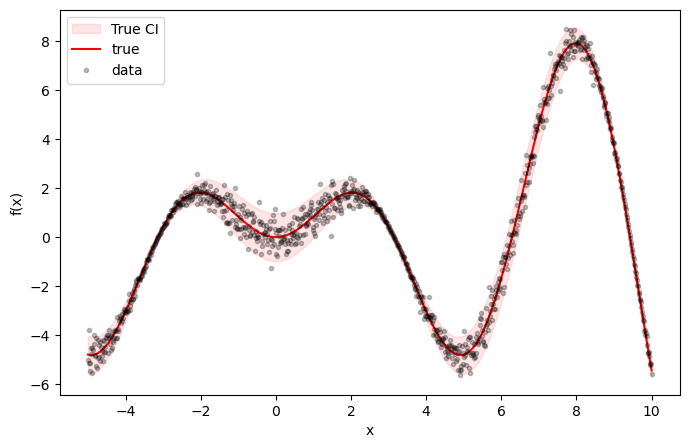

In [2]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=0.5)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [41]:
mlp = MLP(in_channels=1, out_channels=1, hidden_channels=100, layers=2, nonlin='elu', norm='none')
hnet = HyperNet(mlp, stochastic_channels=2, width=100, learn_pz=True, nvp_kwargs={'hidden_dim':64, 
'num_layers':8, 'nonlin':'elu', 'mask_type':'alternating', })

# freeze normalizing flow
#for param in hnet.normalizing_flow.parameters():
#   param.requires_grad = False

optim = torch.optim.Adam(hnet.parameters(), lr=1e-3, weight_decay=0)
crit = EnergyDistanceLoss()

for i in range(500):
    optim.zero_grad()

    yhat = hnet(x.unsqueeze(1), samples=100)
    loss = crit(yhat, y.unsqueeze(1))
    loss.backward()
    optim.step()

    print(f'Epoch {i}, loss: {loss.item()}', end='\r')



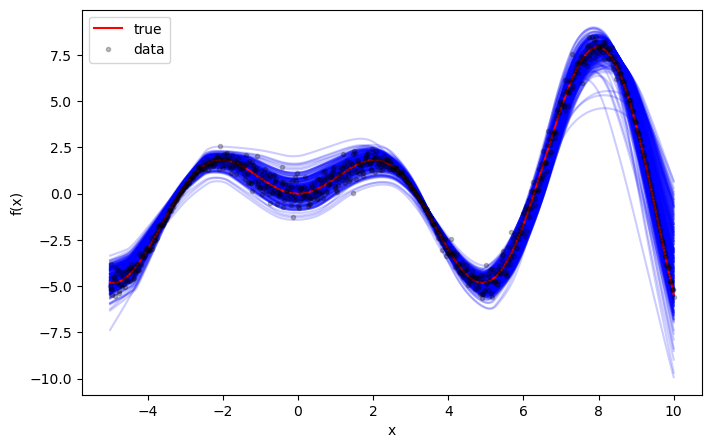

In [42]:
hnet.eval() 
yhat = hnet(x.unsqueeze(1), samples=250)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=False)



In [38]:

# unfreeze normalizing flow
for param in hnet.normalizing_flow.parameters():
    param.requires_grad = True 

# freeze all other parameters (f_phi)
for param in hnet.f_phi.parameters():
    param.requires_grad = False

optim = torch.optim.AdamW(hnet.normalizing_flow.parameters(), lr=1e-3, weight_decay=1e-2)
crit = EnergyDistanceLoss()

hnet.train()
for i in range(500):
    optim.zero_grad()

    yhat = hnet(x.unsqueeze(1), samples=100)
    loss = crit(yhat, y.unsqueeze(1))
    loss.backward()

    torch.nn.utils.clip_grad_norm_(hnet.parameters(), 1)

    optim.step()

    print(f'Epoch {i}, loss: {loss.item()}', end='\r')




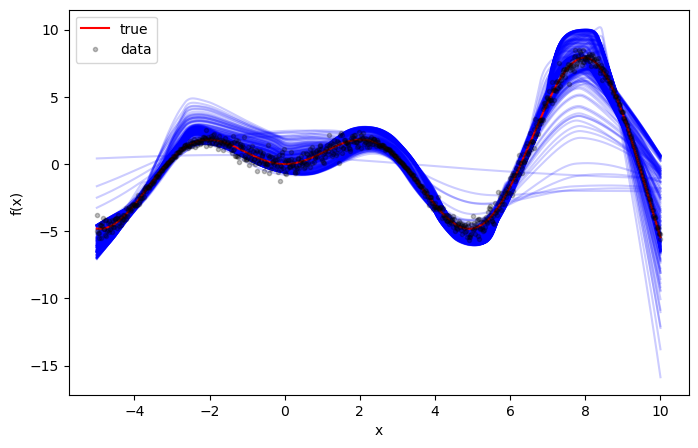

In [39]:
hnet.eval() 
yhat = hnet(x.unsqueeze(1), samples=250)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2=x, yhat=yhat, plot_ci=False)



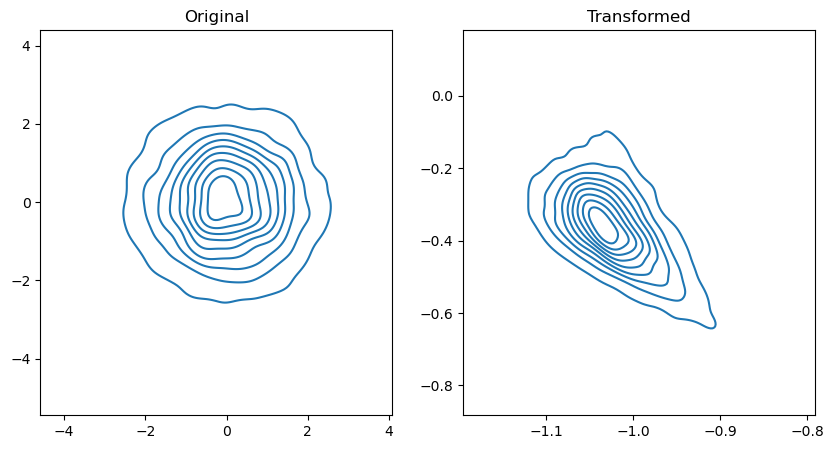

In [43]:
zn = torch.randn(5000, 2) 

zz = hnet.normalizing_flow(zn)

# plot the two distributions

import seaborn as sbn 

f,axes = plt.subplots(1,2, figsize=(10,5))

# contour plot of the two distributions
sbn.kdeplot(x=zz[:,0].detach().cpu().numpy(), y=zz[:,1].detach().cpu().numpy(), ax=axes[1])
sbn.kdeplot(x=zn[:,0].detach().cpu().numpy(), y=zn[:,1].detach().cpu().numpy(), ax=axes[0])

axes[0].set_title('Original')
axes[1].set_title('Transformed')

plt.show()

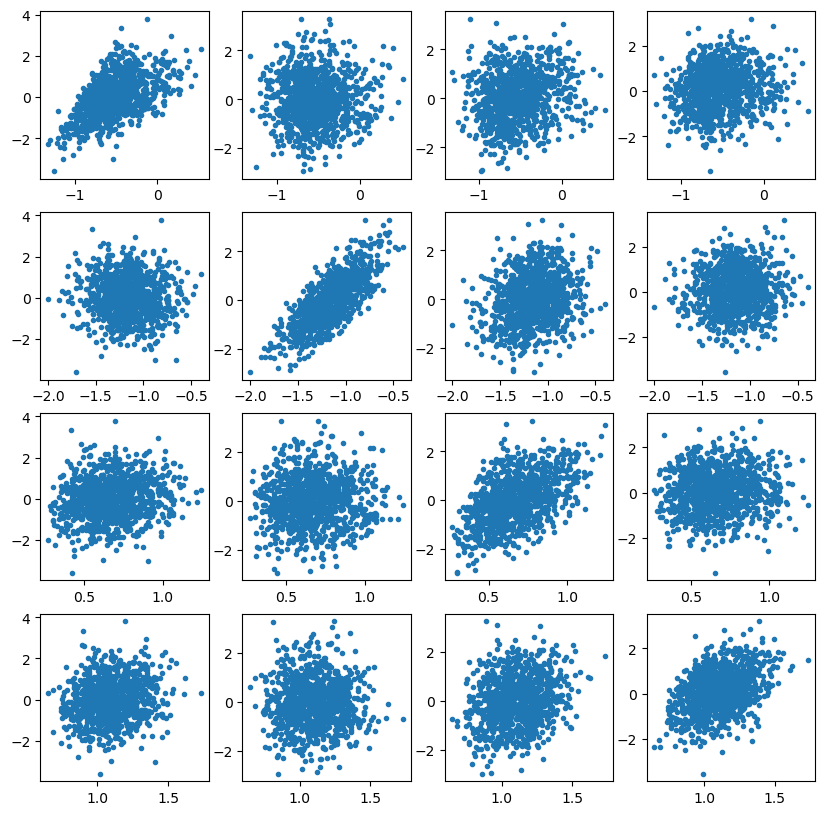

In [25]:


zn = torch.randn(1000, 20) 

zz = hnet.normalizing_flow(zn)

f,axes = plt.subplots(4,4, figsize=(10,10))

for i in range(4):
    for j in range(4):
        axes[i,j].plot(zz[:,i].detach().cpu().numpy(), zn[:,j].detach().cpu().numpy(), '.')

plt.show()